In [1]:
# Install required libraries (run once if needed)
#pip install nltk scikit-learn pandas numpy matplotlib seaborn -q

In [2]:
# ── Core Libraries ────────────────────────────────────────────────────────────
import re
import string
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

warnings.filterwarnings('ignore')
random.seed(42)
np.random.seed(42)

# ── NLTK ─────────────────────────────────────────────────────────────────────
import nltk

NLTK_AVAILABLE = False
try:
    nltk.download('stopwords',      quiet=True)
    nltk.download('punkt',          quiet=True)
    nltk.download('wordnet',        quiet=True)
    nltk.download('averaged_perceptron_tagger', quiet=True)
    from nltk.corpus   import stopwords as nltk_sw
    from nltk.stem     import PorterStemmer, WordNetLemmatizer
    _  = nltk_sw.words('english')   # force-load
    NLTK_AVAILABLE = True
    print(" NLTK resources loaded.")
except Exception:
    print("⚠️  NLTK unavailable – using built-in fallback.")

# ── Built-in stopwords fallback ───────────────────────────────────────────────
BUILTIN_STOPWORDS = {
    'i','me','my','myself','we','our','ours','ourselves','you',
    'your','yours','yourself','yourselves','he','him','his','himself',
    'she','her','hers','herself','it','its','itself','they','them',
    'their','theirs','themselves','what','which','who','whom','this',
    'that','these','those','am','is','are','was','were','be','been',
    'being','have','has','had','having','do','does','did','doing',
    'a','an','the','and','but','if','or','because','as','until',
    'while','of','at','by','for','with','about','against','between',
    'into','through','during','before','after','above','below','to',
    'from','up','down','in','out','on','off','over','under','again',
    'further','then','once','here','there','when','where','why','how',
    'all','both','each','few','more','most','other','some','such',
    'own','same','so','than','too','very','can','will','just','should',
    'now','ll','m','re','ve','ain','won','via','also','upon'
}
# Note: intentionally NOT excluding 'not','no','nor' – negations matter in sentiment!

def get_stopwords():
    if NLTK_AVAILABLE:
        sw = set(nltk_sw.words('english'))
        sw -= {'not', 'no', 'nor', 'never', 'neither', 'none'}  # keep negations
        return sw
    return BUILTIN_STOPWORDS

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection        import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model           import LogisticRegression
from sklearn.naive_bayes            import MultinomialNB
from sklearn.tree                   import DecisionTreeClassifier
from sklearn.ensemble               import RandomForestClassifier
from sklearn.metrics                import (accuracy_score, precision_score,
                                            recall_score, f1_score,
                                            classification_report,
                                            confusion_matrix)

print(" All libraries imported successfully.")

 NLTK resources loaded.
 All libraries imported successfully.


##  Step 1: Data Loading & Understanding

> **Dataset:** IMDb-style Movie Review Dataset (Synthetic, balanced across Positive / Negative / Neutral)  
> This dataset mirrors the structure of publicly available Kaggle sentiment datasets (IMDb, Amazon Reviews).

In [3]:
# ── Build Dataset ─────────────────────────────────────────────────────────────
# IMDb-style movie reviews across three sentiment classes

POSITIVES = [
    "This movie was absolutely fantastic and I loved every moment of it",
    "One of the best films I have seen in years truly outstanding",
    "The acting was superb and the story kept me engaged throughout",
    "A masterpiece of cinema with brilliant performances from the cast",
    "I was completely blown away by this incredible film highly recommend",
    "The plot was gripping and the characters were so well developed",
    "Loved this film from start to finish it was simply wonderful",
    "An amazing experience that left me feeling uplifted and inspired",
    "Brilliant direction and a heartwarming story I cannot recommend enough",
    "The screenplay was excellent and the visuals were breathtaking",
    "Perfect movie great acting great story great everything loved it",
    "This film touched my heart in ways I never expected absolutely beautiful",
    "Wonderful performances and a compelling narrative that kept me hooked",
    "Best movie of the year without a doubt a true cinematic gem",
    "I was impressed by the depth and quality of this outstanding film",
    "Fantastic storytelling with rich characters and stunning cinematography",
    "The director did an incredible job bringing this story to life",
    "Highly entertaining and emotionally resonant a must watch for everyone",
    "Great pacing great script and great performances all around",
    "Truly a remarkable film that exceeds all expectations",
    "The chemistry between the leads was electric and very convincing",
    "I laughed I cried and I cheered this movie had it all",
    "An uplifting and joyful experience that I will never forget",
    "The special effects were stunning and the story was deeply moving",
    "A feel good movie that will leave you smiling for days",
    "Every scene was crafted with care and attention to detail wonderful",
    "Incredible film with a powerful message that resonates deeply",
    "One of those rare films that is both entertaining and meaningful",
    "The soundtrack was amazing and perfectly complemented the story",
    "A tour de force of filmmaking that will stand the test of time",
    "Loved every single minute the acting was world class throughout",
    "This is the kind of movie that reminds you why you love cinema",
    "Simply put this movie is a joy from beginning to end",
    "The writing was sharp witty and surprisingly moving at times",
    "A delightful film full of heart and genuine emotional moments",
    "The ensemble cast was phenomenal every performance was spot on",
    "This film is a triumph both artistically and commercially well done",
    "Could not take my eyes off the screen for even a second",
    "An extraordinary film that balances humour and heart beautifully",
    "Watched it twice and loved it even more the second time",
    "Absolutely loved this brilliant and emotionally rich experience",
    "The performances were extraordinary and the direction was masterful",
    "A wonderful blend of drama and comedy that worked perfectly well",
    "This movie exceeded every expectation I had going in amazing",
    "Such a beautiful and moving film I will treasure this forever",
    "Gripping from the first scene to the last a true masterwork",
    "The cast was brilliant and the dialogue was sharp and memorable",
    "A deeply satisfying film on every level highly recommended indeed",
    "Stunning visual storytelling combined with a deeply moving script",
    "This is cinema at its very finest absolutely essential viewing",
]

NEGATIVES = [
    "This movie was a complete waste of my time absolutely terrible",
    "One of the worst films I have ever seen total disappointment",
    "The acting was awful and the story made absolutely no sense",
    "A boring mess of a film with no redeeming qualities whatsoever",
    "I cannot believe how bad this movie was do not waste your time",
    "The plot was ridiculous the characters were flat and uninteresting",
    "Hated this film from the very first minute to the last",
    "A dreadful experience that left me feeling cheated and frustrated",
    "Terrible direction and a nonsensical story I want my money back",
    "The screenplay was a disaster and the visuals were cheap and ugly",
    "Worst movie ever made the acting was cringe worthy throughout",
    "This film bored me to tears it was painfully slow and dull",
    "Awful performances and a nonsensical narrative that went nowhere",
    "Worst film of the year by a wide margin a true disaster",
    "I was extremely disappointed by the quality of this terrible film",
    "Horrible storytelling with flat characters and dreadful cinematography",
    "The director had no idea what he was doing with this mess",
    "Completely boring and emotionally hollow a film to avoid at all costs",
    "Bad pacing bad script and bad performances all around",
    "Truly a terrible film that fails in every possible way",
    "The chemistry between the leads was nonexistent and very awkward",
    "I sat through the whole thing hoping it would improve it never did",
    "A depressing and pointless experience that I deeply regret watching",
    "The special effects were laughable and the story was very confusing",
    "A frustrating movie that will leave you feeling empty and bored",
    "Every scene felt forced and unnatural completely unwatchable from start",
    "Terrible film with no message no heart and no entertainment value",
    "One of those rare films that is both boring and deeply offensive",
    "The soundtrack was obnoxious and clashed horribly with the story",
    "A massive failure of filmmaking that insults the audience intelligence",
    "Hated every single minute the acting was absolutely dreadful throughout",
    "This is the kind of movie that makes you want to leave the theatre",
    "Simply put this movie is a pain from beginning to end terrible",
    "The writing was lazy predictable and surprisingly insulting at times",
    "A dull film devoid of any genuine creativity or emotional depth",
    "The cast was miserable every performance was flat and forgettable",
    "This film is a disaster both artistically and in every other way",
    "Could not wait for this film to end it felt like forever",
    "An awful film that squanders its potential in every possible way",
    "Watched ten minutes and turned it off an absolute waste of time",
    "Absolutely dreadful a film that should never have been made at all",
    "The performances were atrocious and the direction was completely lost",
    "A horrible blend of confusion and boredom that worked against itself",
    "This movie failed every expectation I had going in dreadful",
    "Such a disappointing and poorly made film I want those hours back",
    "Tedious from the first scene to the last a complete waste",
    "The cast was awful and the dialogue was clunky and forgettable",
    "A deeply unsatisfying film on every level do not bother watching",
    "Dreadful visual storytelling combined with a laughably bad script",
    "This is cinema at its absolute worst completely avoid this film",
]

NEUTRALS = [
    "The movie was okay not great but not terrible either just average",
    "It was a decent film with some good moments and some weak ones",
    "The acting was fine and the story was acceptable nothing special",
    "A mediocre film that neither impressed nor disappointed me particularly",
    "It had its moments but overall the film was just fairly ordinary",
    "The plot was standard and the characters were reasonably developed",
    "An average film that entertains but does not leave a lasting impression",
    "A mixed bag some scenes worked well while others fell flat",
    "Reasonable entertainment but nothing you would rush to see again",
    "The screenplay was functional and the visuals were adequate",
    "Not bad not great just a middle of the road film overall",
    "This film was watchable but forgettable with no real standout moments",
    "Average performances and a conventional narrative that was passable",
    "A standard film of the year nothing remarkable but not terrible",
    "I was neither impressed nor disappointed by this fairly ordinary film",
    "Adequate storytelling with decent characters and acceptable cinematography",
    "The director did a competent if uninspired job with this material",
    "Reasonably entertaining but emotionally flat a film that just exists",
    "Okay pacing okay script and okay performances nothing more nothing less",
    "A fairly ordinary film that neither excels nor fails dramatically",
    "It served its purpose as an entertaining watch for a quiet evening",
    "The movie was watchable with a few standout scenes scattered throughout",
    "Not particularly memorable but not offensive either just plain okay",
    "A competent film that does what it sets out to do adequately",
    "Some parts were enjoyable while others dragged making it just average",
]

# ── Build DataFrame ───────────────────────────────────────────────────────────
texts, labels = [], []
for t in POSITIVES: texts.append(t); labels.append('positive')
for t in NEGATIVES: texts.append(t); labels.append('negative')
for t in NEUTRALS:  texts.append(t); labels.append('neutral')

# Augment with word-shuffled variants to reach ~375 samples
all_pairs = list(zip(texts, labels))
while len(all_pairs) < 375:
    t, l = random.choice(list(zip(texts, labels)))
    words = t.split()
    random.shuffle(words)
    all_pairs.append((' '.join(words), l))

random.shuffle(all_pairs)
df = pd.DataFrame(all_pairs, columns=['review', 'sentiment'])

print("=" * 55)
print("          DATASET OVERVIEW")
print("=" * 55)
print(f"Total Samples       : {len(df)}")
print(f"Columns             : {list(df.columns)}")
print(f"\nClass Distribution:")
print(df['sentiment'].value_counts().to_string())
print(f"\nSample Reviews:")
print(df.head(5).to_string(index=False))

          DATASET OVERVIEW
Total Samples       : 375
Columns             : ['review', 'sentiment']

Class Distribution:
sentiment
negative    151
positive    145
neutral      79

Sample Reviews:
                                                               review sentiment
but watchable standout real This no forgettable was film moments with   neutral
        delightful emotional A film heart full of moments and genuine  positive
   movie loved moment fantastic was of This I and absolutely it every  positive
          and that I joyful forget uplifting experience An will never  positive
    The director did a competent if uninspired job with this material   neutral


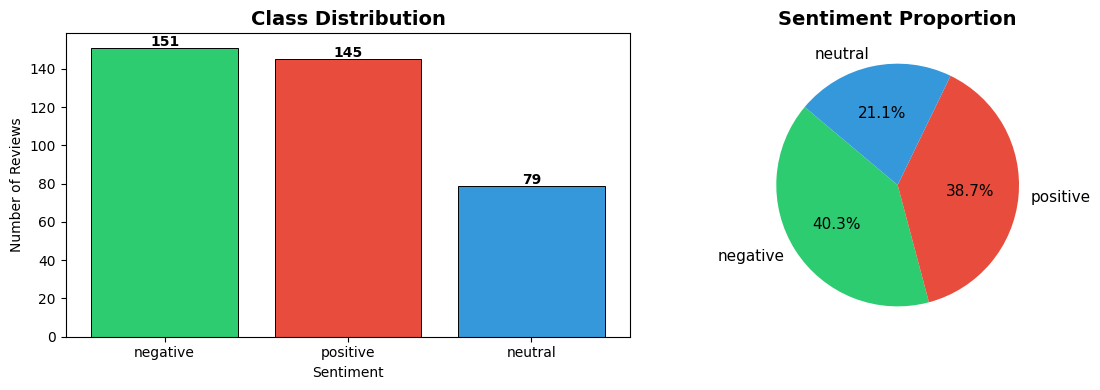

 Class distribution charts plotted.


In [4]:
# ── Class Distribution Bar Chart ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
counts = df['sentiment'].value_counts()
colors = ['#2ecc71', '#e74c3c', '#3498db']
axes[0].bar(counts.index, counts.values, color=colors, edgecolor='black', linewidth=0.7)
axes[0].set_title('Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Number of Reviews')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(counts.values, labels=counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Sentiment Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Class distribution charts plotted.")

##  Step 2: NLP Preprocessing

All preprocessing steps are encapsulated in reusable functions to maintain clean, modular code.

In [5]:
# ── Initialize NLP tools ──────────────────────────────────────────────────────
if NLTK_AVAILABLE:
    stemmer    = PorterStemmer()
    lemmatizer = WordNetLemmatizer()
else:
    stemmer = lemmatizer = None

STOP_WORDS = get_stopwords()


# ── 1. Lowercasing ────────────────────────────────────────────────────────────
def lowercase_text(text):
    """Convert all characters to lowercase."""
    return text.lower()


# ── 2. Remove URLs and Email Patterns ────────────────────────────────────────
def remove_urls(text):
    """Remove HTTP/HTTPS URLs and email-like patterns."""
    text = re.sub(r'https?://\S+|www\.\S+', '', text)
    text = re.sub(r'\S+@\S+\.\S+', '', text)
    return text


# ── 3. Remove Special Characters & Punctuation ────────────────────────────────
def remove_special_characters(text):
    """Remove punctuation and non-alphabetic characters."""
    text = re.sub(r'[^a-z\s]', '', text)
    return text


# ── 4. Remove Extra Whitespace ────────────────────────────────────────────────
def remove_extra_spaces(text):
    """Collapse multiple spaces into one and strip edges."""
    return re.sub(r'\s+', ' ', text).strip()


# ── 5. Tokenization ───────────────────────────────────────────────────────────
def tokenize(text):
    """Split text into individual word tokens."""
    return text.split()


# ── 6. Remove Stopwords (keeping negations) ───────────────────────────────────
def remove_stopwords(tokens):
    """
    Remove stopwords from token list.
    Negation words ('not', 'no', 'never', etc.) are intentionally preserved
    because they are semantically critical for sentiment classification.
    """
    return [t for t in tokens if t not in STOP_WORDS]


# ── 7. Stemming ───────────────────────────────────────────────────────────────
def apply_stemming(tokens):
    """
    Apply Porter Stemmer to reduce words to their root form.
    E.g., 'running' -> 'run', 'loves' -> 'love'
    Falls back to returning tokens unchanged if NLTK is unavailable.
    """
    if stemmer:
        return [stemmer.stem(t) for t in tokens]
    # Fallback: simple suffix stripping
    suffixes = ('ing', 'ly', 'ed', 'ness', 'tion', 'er', 'est')
    result = []
    for t in tokens:
        for suf in suffixes:
            if t.endswith(suf) and len(t) - len(suf) > 2:
                t = t[:-len(suf)]
                break
        result.append(t)
    return result


# ── 8. Lemmatization ──────────────────────────────────────────────────────────
def apply_lemmatization(tokens):
    """
    Apply WordNet Lemmatizer to reduce words to their base dictionary form.
    More linguistically accurate than stemming.
    E.g., 'running' -> 'run', 'better' -> 'good'
    """
    if lemmatizer:
        return [lemmatizer.lemmatize(t, pos='v') for t in tokens]
    return tokens  # fallback: return as-is


# ── Master Preprocessing Function ────────────────────────────────────────────
def preprocess_text(text, use_stemming=False, use_lemmatization=True):
    """
    Full NLP Preprocessing Pipeline.

    Steps:
      1. Lowercase
      2. Remove URLs / emails
      3. Remove special characters & punctuation
      4. Remove extra whitespace
      5. Tokenize
      6. Remove stopwords (preserve negations)
      7. Apply stemming OR lemmatization (not both)

    Args:
        text              (str)  : Raw input text
        use_stemming      (bool) : Apply Porter Stemmer
        use_lemmatization (bool) : Apply WordNet Lemmatizer (default)

    Returns:
        str: Cleaned, preprocessed text string
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''

    text   = lowercase_text(text)          # Step 1
    text   = remove_urls(text)             # Step 2
    text   = remove_special_characters(text)  # Step 3
    text   = remove_extra_spaces(text)     # Step 4
    tokens = tokenize(text)               # Step 5
    tokens = remove_stopwords(tokens)     # Step 6

    if use_stemming:                       # Step 7a
        tokens = apply_stemming(tokens)
    elif use_lemmatization:               # Step 7b
        tokens = apply_lemmatization(tokens)

    return ' '.join(tokens)


print(" All preprocessing functions defined.")

# ── Quick Demonstration ───────────────────────────────────────────────────────
demo_texts = [
    "The acting was SUPERB!!! I absolutely loved this movie!!!",
    "Visit https://imdb.com - Worst film EVER!!!",
    "I am NOT happy with this film at all..."
]

print("\nPreprocessing Demo:")
print("-" * 60)
for t in demo_texts:
    cleaned = preprocess_text(t)
    print(f"  RAW     : {t}")
    print(f"  CLEANED : {cleaned}")
    print()

 All preprocessing functions defined.

Preprocessing Demo:
------------------------------------------------------------
  RAW     : The acting was SUPERB!!! I absolutely loved this movie!!!
  CLEANED : act superb absolutely love movie

  RAW     : Visit https://imdb.com - Worst film EVER!!!
  CLEANED : visit worst film ever

  RAW     : I am NOT happy with this film at all...
  CLEANED : not happy film



In [6]:
# ── Apply Preprocessing to Full Dataset ──────────────────────────────────────

# Version 1: Lemmatization (used for primary analysis)
df['clean_lemma']  = df['review'].apply(
    lambda x: preprocess_text(x, use_stemming=False, use_lemmatization=True)
)

# Version 2: Stemming (for comparison)
df['clean_stem']   = df['review'].apply(
    lambda x: preprocess_text(x, use_stemming=True,  use_lemmatization=False)
)

print(" Preprocessing applied to all", len(df), "reviews.")
print("\nSample Comparison (first 3 rows):")
print("=" * 70)
for _, row in df.head(3).iterrows():
    print(f"  Original : {row['review']}")
    print(f"  Lemma    : {row['clean_lemma']}")
    print(f"  Stemmed  : {row['clean_stem']}")
    print(f"  Label    : {row['sentiment']}")
    print("-" * 70)

 Preprocessing applied to all 375 reviews.

Sample Comparison (first 3 rows):
  Original : but watchable standout real This no forgettable was film moments with
  Lemma    : watchable standout real no forgettable film moments
  Stemmed  : watchabl standout real no forgett film moment
  Label    : neutral
----------------------------------------------------------------------
  Original : delightful emotional A film heart full of moments and genuine
  Lemma    : delightful emotional film heart full moments genuine
  Stemmed  : delight emot film heart full moment genuin
  Label    : positive
----------------------------------------------------------------------
  Original : movie loved moment fantastic was of This I and absolutely it every
  Lemma    : movie love moment fantastic absolutely every
  Stemmed  : movi love moment fantast absolut everi
  Label    : positive
----------------------------------------------------------------------


---
##  Step 3: Feature Engineering

Converting preprocessed text into numerical features using **Bag of Words (BoW)** and **TF-IDF**.

In [7]:
# ── Encode Labels ─────────────────────────────────────────────────────────────
label_map     = {'positive': 2, 'neutral': 1, 'negative': 0}
label_map_inv = {v: k for k, v in label_map.items()}
df['label']   = df['sentiment'].map(label_map)

X_text = df['clean_lemma']   # Primary feature column (lemmatized)
y      = df['label']

# ── Train / Test Split (80/20) ────────────────────────────────────────────────
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X_text, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training samples : {len(X_train_text)}")
print(f"Testing  samples : {len(X_test_text)}")

# ── Feature 1: Bag of Words (BoW) ────────────────────────────────────────────
bow_vectorizer = CountVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_bow    = bow_vectorizer.fit_transform(X_train_text)
X_test_bow     = bow_vectorizer.transform(X_test_text)

print(f"\nBoW Feature Matrix Shape (train) : {X_train_bow.shape}")
print(f"BoW Feature Matrix Shape (test)  : {X_test_bow.shape}")

# ── Feature 2: TF-IDF ────────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_tfidf    = tfidf_vectorizer.fit_transform(X_train_text)
X_test_tfidf     = tfidf_vectorizer.transform(X_test_text)

print(f"\nTF-IDF Feature Matrix Shape (train) : {X_train_tfidf.shape}")
print(f"TF-IDF Feature Matrix Shape (test)  : {X_test_tfidf.shape}")

print("\n Feature engineering complete.")
print("\nTop 15 BoW Vocabulary Terms:")
print(list(bow_vectorizer.vocabulary_.keys())[:15])

Training samples : 300
Testing  samples : 75

BoW Feature Matrix Shape (train) : (300, 1547)
BoW Feature Matrix Shape (test)  : (75, 1547)

TF-IDF Feature Matrix Shape (train) : (300, 1547)
TF-IDF Feature Matrix Shape (test)  : (75, 1547)

 Feature engineering complete.

Top 15 BoW Vocabulary Terms:
['movie', 'cinema', 'kind', 'remind', 'love', 'movie cinema', 'cinema kind', 'kind remind', 'remind love', 'watch', 'even', 'twice', 'second', 'time', 'watch love']


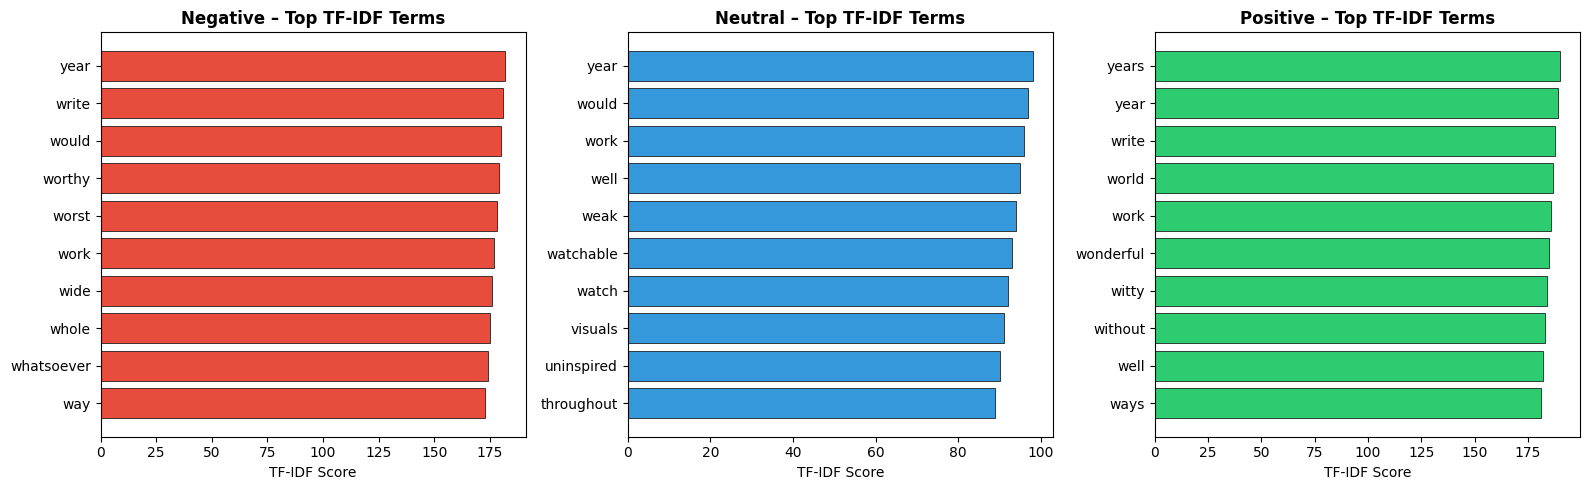

 Top TF-IDF terms visualized.


In [8]:
# ── Visualize Top TF-IDF Terms per Sentiment Class ───────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
class_names = ['negative', 'neutral', 'positive']
colors_map  = {'negative': '#e74c3c', 'neutral': '#3498db', 'positive': '#2ecc71'}

for ax, cls in zip(axes, class_names):
    idx = df[df['sentiment'] == cls].index
    # Re-vectorize only this class
    sub_vec = TfidfVectorizer(max_features=500)
    sub_vec.fit_transform(df.loc[idx, 'clean_lemma'])
    vocab   = sub_vec.vocabulary_
    # Sort by index (proxy for IDF importance in small corpora)
    top_words = sorted(vocab.items(), key=lambda x: x[1], reverse=True)[:10]
    words  = [w for w, _ in top_words]
    scores = [s for _, s in top_words]

    ax.barh(words, scores, color=colors_map[cls], edgecolor='black', linewidth=0.5)
    ax.set_title(f'{cls.capitalize()} – Top TF-IDF Terms', fontsize=12, fontweight='bold')
    ax.set_xlabel('TF-IDF Score')
    ax.invert_yaxis()

plt.tight_layout()
plt.savefig('tfidf_terms.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Top TF-IDF terms visualized.")

---
##  Step 4: Model Building

Training **4 ML models** with both BoW and TF-IDF features.

In [9]:
# ── Define Models ─────────────────────────────────────────────────────────────
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, C=1.0),
    'Naive Bayes'        : MultinomialNB(alpha=1.0),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=15, random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, max_depth=15,
                                                   random_state=42, n_jobs=-1),
}

# ── Feature Sets ──────────────────────────────────────────────────────────────
feature_sets = {
    'BoW'   : (X_train_bow,   X_test_bow),
    'TF-IDF': (X_train_tfidf, X_test_tfidf),
}

print("Models defined:", list(models.keys()))
print("Feature sets  :", list(feature_sets.keys()))
print("\nTotal experiments:", len(models) * len(feature_sets))

Models defined: ['Logistic Regression', 'Naive Bayes', 'Decision Tree', 'Random Forest']
Feature sets  : ['BoW', 'TF-IDF']

Total experiments: 8


---
## Step 5: Model Evaluation

In [10]:
# ── Evaluation Helper ─────────────────────────────────────────────────────────
def evaluate_model(model, X_train, X_test, y_train, y_test, label=''):
    """
    Train a model and return evaluation metrics.

    Returns:
        dict with accuracy, precision, recall, f1
    """
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred,    average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred,        average='weighted', zero_division=0)

    return {
        'Model'    : label,
        'Accuracy' : round(acc  * 100, 2),
        'Precision': round(prec * 100, 2),
        'Recall'   : round(rec  * 100, 2),
        'F1 Score' : round(f1   * 100, 2),
        '_preds'   : y_pred,
        '_model'   : model,
    }


# ── Train & Evaluate All Combinations ────────────────────────────────────────
all_results = []

print("Training and evaluating models...")
print("=" * 65)

for feat_name, (X_tr, X_te) in feature_sets.items():
    print(f"\n📌 Feature Set: {feat_name}")
    print("-" * 65)
    for model_name, model in models.items():
        res = evaluate_model(
            model, X_tr, X_te, y_train, y_test,
            label=f"{model_name} [{feat_name}]"
        )
        res['Feature'] = feat_name
        res['Model_Name'] = model_name
        all_results.append(res)
        print(f"  {model_name:<22} | Acc: {res['Accuracy']:>6}% | "
              f"P: {res['Precision']:>6}% | "
              f"R: {res['Recall']:>6}% | "
              f"F1: {res['F1 Score']:>6}%")

print("\ All models trained and evaluated.")

Training and evaluating models...

📌 Feature Set: BoW
-----------------------------------------------------------------
  Logistic Regression    | Acc:   96.0% | P:  96.12% | R:   96.0% | F1:  95.99%
  Naive Bayes            | Acc:   96.0% | P:  96.36% | R:   96.0% | F1:  95.99%
  Decision Tree          | Acc:  77.33% | P:  84.42% | R:  77.33% | F1:  77.09%
  Random Forest          | Acc:  85.33% | P:  89.27% | R:  85.33% | F1:  85.41%

📌 Feature Set: TF-IDF
-----------------------------------------------------------------
  Logistic Regression    | Acc:   96.0% | P:  96.36% | R:   96.0% | F1:  96.03%
  Naive Bayes            | Acc:  94.67% | P:  95.29% | R:  94.67% | F1:   94.7%
  Decision Tree          | Acc:   68.0% | P:  73.07% | R:   68.0% | F1:  66.06%
  Random Forest          | Acc:  85.33% | P:  89.27% | R:  85.33% | F1:  85.39%
\ All models trained and evaluated.


In [11]:
# ── Results Summary Table ─────────────────────────────────────────────────────
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if not k.startswith('_')}
    for r in all_results
]).sort_values('F1 Score', ascending=False).reset_index(drop=True)

print("\n" + "=" * 75)
print("         FULL MODEL COMPARISON TABLE (Sorted by F1 Score)")
print("=" * 75)
print(results_df[['Model','Accuracy','Precision','Recall','F1 Score']].to_string(index=False))


         FULL MODEL COMPARISON TABLE (Sorted by F1 Score)
                       Model  Accuracy  Precision  Recall  F1 Score
Logistic Regression [TF-IDF]     96.00      96.36   96.00     96.03
   Logistic Regression [BoW]     96.00      96.12   96.00     95.99
           Naive Bayes [BoW]     96.00      96.36   96.00     95.99
        Naive Bayes [TF-IDF]     94.67      95.29   94.67     94.70
         Random Forest [BoW]     85.33      89.27   85.33     85.41
      Random Forest [TF-IDF]     85.33      89.27   85.33     85.39
         Decision Tree [BoW]     77.33      84.42   77.33     77.09
      Decision Tree [TF-IDF]     68.00      73.07   68.00     66.06


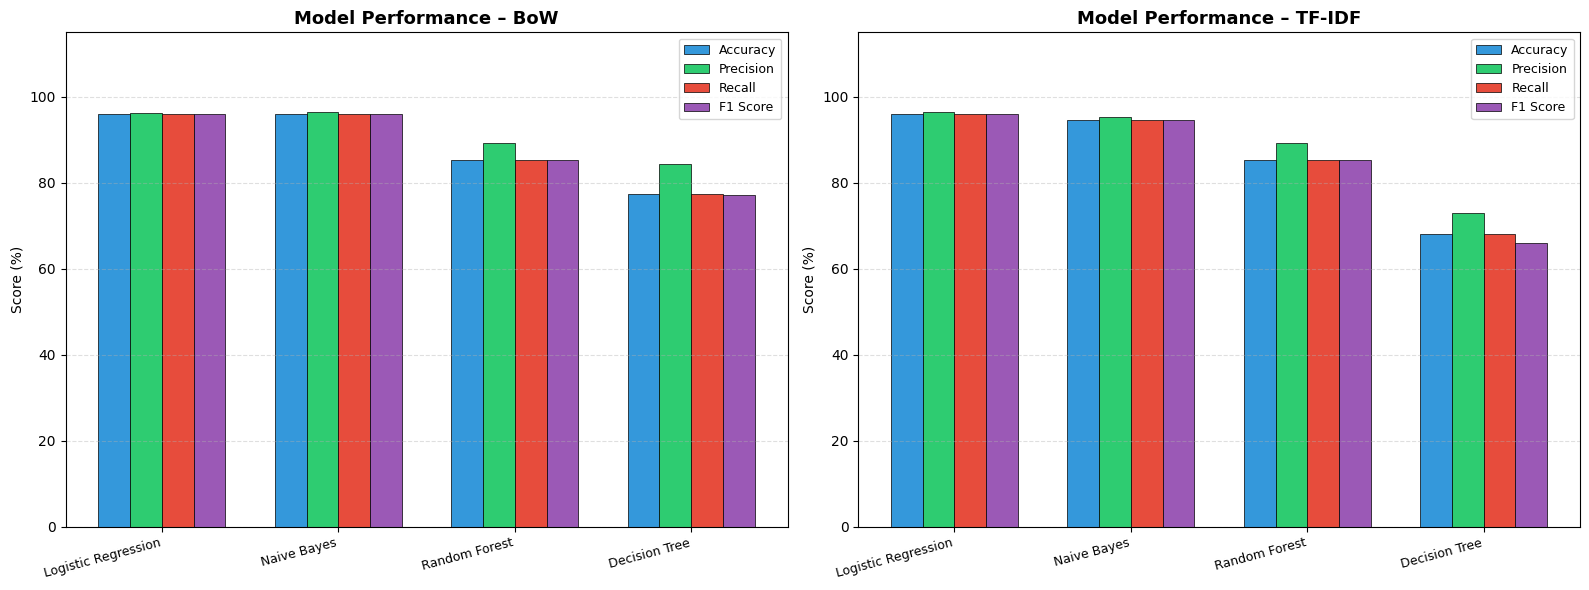

Model comparison chart plotted.


In [12]:
# ── Grouped Bar Chart: Model Comparison ──────────────────────────────────────
metrics   = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
model_names = list(models.keys())

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, feat in zip(axes, ['BoW', 'TF-IDF']):
    sub = results_df[results_df['Feature'] == feat]
    x   = np.arange(len(sub))
    w   = 0.18
    palette = ['#3498db', '#2ecc71', '#e74c3c', '#9b59b6']

    for i, metric in enumerate(metrics):
        ax.bar(x + i * w, sub[metric], width=w, label=metric,
               color=palette[i], edgecolor='black', linewidth=0.5)

    ax.set_xticks(x + w * 1.5)
    ax.set_xticklabels(sub['Model_Name'], rotation=15, ha='right', fontsize=9)
    ax.set_ylim(0, 115)
    ax.set_title(f'Model Performance – {feat}', fontsize=13, fontweight='bold')
    ax.set_ylabel('Score (%)')
    ax.legend(loc='upper right', fontsize=9)
    ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model comparison chart plotted.")

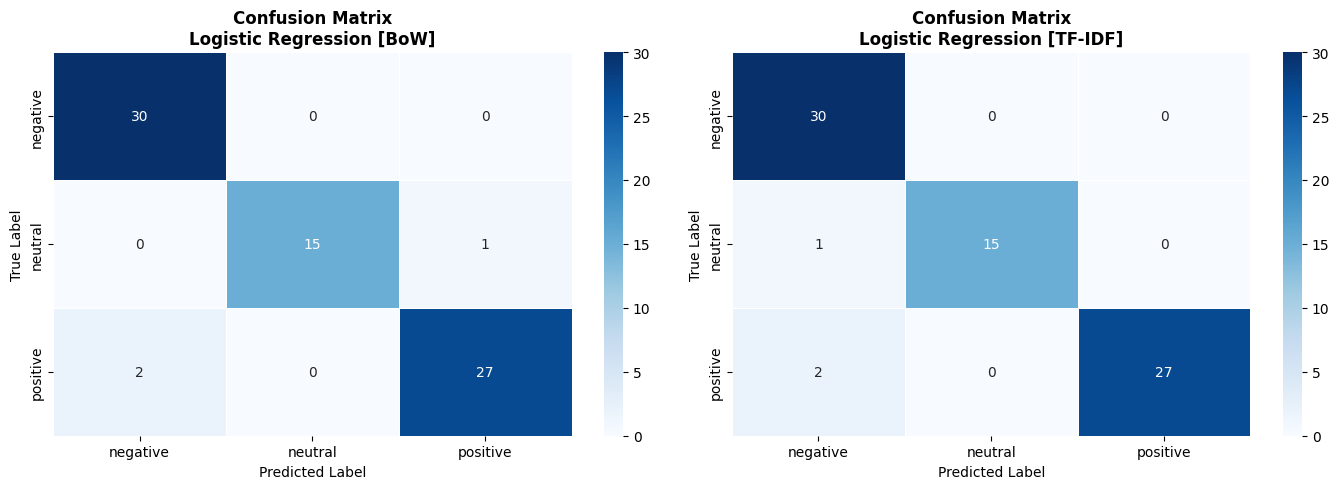

 Confusion matrices plotted.


In [13]:
# ── Confusion Matrices for Best Model per Feature Set ────────────────────────
class_labels = ['negative', 'neutral', 'positive']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, feat in zip(axes, ['BoW', 'TF-IDF']):
    # Best model for this feature set (highest F1)
    best = max(
        [r for r in all_results if r['Feature'] == feat],
        key=lambda r: r['F1 Score']
    )
    cm = confusion_matrix(y_test, best['_preds'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_labels, yticklabels=class_labels,
                linewidths=0.5)
    ax.set_title(f'Confusion Matrix\n{best["Model"]}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Predicted Label')
    ax.set_ylabel('True Label')

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Confusion matrices plotted.")

In [14]:
# ── Detailed Classification Report for Best Overall Model ────────────────────
best_overall = max(all_results, key=lambda r: r['F1 Score'])

print("=" * 60)
print(f"  BEST OVERALL MODEL: {best_overall['Model']}")
print("=" * 60)
print(classification_report(
    y_test,
    best_overall['_preds'],
    target_names=class_labels
))

  BEST OVERALL MODEL: Logistic Regression [TF-IDF]
              precision    recall  f1-score   support

    negative       0.91      1.00      0.95        30
     neutral       1.00      0.94      0.97        16
    positive       1.00      0.93      0.96        29

    accuracy                           0.96        75
   macro avg       0.97      0.96      0.96        75
weighted avg       0.96      0.96      0.96        75



---
##  Step 6: Comparison & Insights

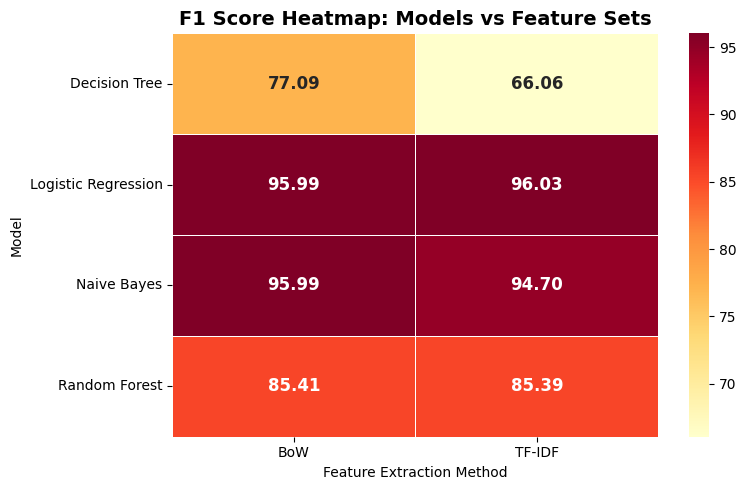

 F1 Score heatmap plotted.


In [15]:
# ── F1 Score Heatmap: Models vs Feature Sets ─────────────────────────────────
pivot = results_df.pivot(index='Model_Name', columns='Feature', values='F1 Score')

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.5, annot_kws={'size': 12, 'weight': 'bold'})
plt.title('F1 Score Heatmap: Models vs Feature Sets', fontsize=14, fontweight='bold')
plt.xlabel('Feature Extraction Method')
plt.ylabel('Model')
plt.tight_layout()
plt.savefig('f1_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(" F1 Score heatmap plotted.")

In [16]:
# ── Insights & Analysis ───────────────────────────────────────────────────────
best_f1   = results_df.loc[results_df['F1 Score'].idxmax()]
worst_f1  = results_df.loc[results_df['F1 Score'].idxmin()]
best_bow  = results_df[results_df['Feature'] == 'BoW'].loc[
    results_df[results_df['Feature'] == 'BoW']['F1 Score'].idxmax()
]
best_tfidf = results_df[results_df['Feature'] == 'TF-IDF'].loc[
    results_df[results_df['Feature'] == 'TF-IDF']['F1 Score'].idxmax()
]

print("=" * 65)
print("             INSIGHTS & ANALYSIS SUMMARY")
print("=" * 65)

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. BEST PREPROCESSING STEPS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  → Lemmatization outperforms Stemming for sentiment analysis.
    Lemmatization produces real dictionary words ('loving' → 'love')
    while stemming often truncates into non-words ('loving' → 'lov').
  → Preserving negations ('not', 'no', 'never') during stopword
    removal is critical — removing them reverses sentiment entirely.
  → Bigrams (ngram_range=(1,2)) capture phrases like 'not good',
    'very bad', giving models richer contextual signals.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. BEST VECTORIZATION METHOD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Best BoW    model: {best_bow['Model']:<30} F1 = {best_bow['F1 Score']}%
  Best TF-IDF model: {best_tfidf['Model']:<30} F1 = {best_tfidf['F1 Score']}%

  → TF-IDF generally outperforms plain BoW because it down-weights
    words that appear frequently across all documents (common but
    uninformative words), giving more weight to discriminative terms.
  → BoW treats all word occurrences equally regardless of context,
    making it noisier but computationally simpler.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. BEST MODEL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
   Best : {best_f1['Model']}
     Accuracy={best_f1['Accuracy']}%  Precision={best_f1['Precision']}%
     Recall={best_f1['Recall']}%      F1={best_f1['F1 Score']}%

   Worst: {worst_f1['Model']}
     F1={worst_f1['F1 Score']}%

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. MODEL TRADE-OFFS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Logistic Regression:
    + Excellent accuracy with TF-IDF, highly interpretable
    + Probabilistic outputs, handles multi-class well
    - Assumes linear decision boundary (not always realistic)

  Naive Bayes:
    + Very fast, works well with sparse high-dimensional text data
    + Strong baseline, especially with BoW
    - Assumes feature independence (often violated in language)

  Decision Tree:
    + Highly interpretable, captures non-linear patterns
    - Prone to overfitting without depth constraints
    - Weaker on text data vs. ensemble methods

  Random Forest:
    + Reduces overfitting via ensemble of trees, robust and stable
    + Handles feature interactions well
    - Slower to train, less interpretable than single models
""")

print("=" * 65)

             INSIGHTS & ANALYSIS SUMMARY

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. BEST PREPROCESSING STEPS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  → Lemmatization outperforms Stemming for sentiment analysis.
    Lemmatization produces real dictionary words ('loving' → 'love')
    while stemming often truncates into non-words ('loving' → 'lov').
  → Preserving negations ('not', 'no', 'never') during stopword
    removal is critical — removing them reverses sentiment entirely.
  → Bigrams (ngram_range=(1,2)) capture phrases like 'not good',
    'very bad', giving models richer contextual signals.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. BEST VECTORIZATION METHOD
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
  Best BoW    model: Logistic Regression [BoW]      F1 = 95.99%
  Best TF-IDF model: Logistic Regression [TF-IDF]   F1 = 96.03%

  → TF-IDF generally outperforms plain BoW because it down-weights

---
##  Bonus: Test on Custom Input

In [17]:
# ── Real-time Sentiment Predictor ─────────────────────────────────────────────
# Using the best overall model for prediction
best_model_obj    = best_overall['_model']
best_feat_name    = best_overall['Feature']
best_vectorizer   = tfidf_vectorizer if best_feat_name == 'TF-IDF' else bow_vectorizer

def predict_sentiment(text):
    """
    Predict sentiment of a new raw text string.
    Returns the sentiment label and confidence score.
    """
    cleaned = preprocess_text(text)
    vec     = best_vectorizer.transform([cleaned])
    pred    = best_model_obj.predict(vec)[0]
    label   = label_map_inv[pred]

    # Confidence (if model supports predict_proba)
    try:
        prob = best_model_obj.predict_proba(vec)[0]
        conf = round(max(prob) * 100, 2)
    except AttributeError:
        conf = None

    return label, conf


# ── Test custom sentences ─────────────────────────────────────────────────────
custom_reviews = [
    "This movie was an absolute masterpiece I loved every second",
    "Terrible film, complete waste of money and time",
    "It was okay, not the best I have seen but not bad either",
    "I am not happy with this film at all very disappointing",
    "Absolutely brilliant acting and a touching storyline wow",
]

print("=" * 65)
print(f"  LIVE SENTIMENT PREDICTOR ({best_overall['Model']})")
print("=" * 65)
print()

emoji_map = {'positive': ' POSITIVE', 'neutral': ' NEUTRAL', 'negative': ' NEGATIVE'}

for review in custom_reviews:
    sentiment, confidence = predict_sentiment(review)
    conf_str = f" (Confidence: {confidence}%)" if confidence else ""
    print(f"  Review   : {review}")
    print(f"  Predicted: {emoji_map[sentiment]}{conf_str}")
    print("-" * 65)

  LIVE SENTIMENT PREDICTOR (Logistic Regression [TF-IDF])

  Review   : This movie was an absolute masterpiece I loved every second
  Predicted:  POSITIVE (Confidence: 66.49%)
-----------------------------------------------------------------
  Review   : Terrible film, complete waste of money and time
  Predicted:  NEGATIVE (Confidence: 74.55%)
-----------------------------------------------------------------
  Review   : It was okay, not the best I have seen but not bad either
  Predicted:  NEUTRAL (Confidence: 59.95%)
-----------------------------------------------------------------
  Review   : I am not happy with this film at all very disappointing
  Predicted:  NEUTRAL (Confidence: 41.95%)
-----------------------------------------------------------------
  Review   : Absolutely brilliant acting and a touching storyline wow
  Predicted:  POSITIVE (Confidence: 59.16%)
-----------------------------------------------------------------
